# **Notebook 4: Model Prediction (Inferences)**
> ### **Project: PestNeuroVision**
>**Description:** This notebook loads the trained model generated in Notebook 1 to perform inferences on the test set; it also generates feature maps of the predictions made.
>
> ---
>**Dependency:** Uses the trained model (`best.pt`) and specific samples from the test set.
>
> ---
>**License:** This notebook is licensed under the GNU Affero General Public License v3.0 (AGPL-3.0). See details in the [GitHub repository](https://github.com/alexander-lm/PestNeuroVision/tree/main).

In [ ]:
!pip install Ultralytics

In [2]:
import glob
import shutil
import os
from IPython.display import Image, display
from ultralytics import settings, YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
if os.path.exists("trained_model"):
    shutil.rmtree("trained_model")
    print("Folder trained_model deleted.")

if os.path.exists("prediction_dataset"):
    shutil.rmtree("prediction_dataset")
    print("Folder prediction_dataset deleted.")

if os.path.exists('runs/detect/predict'):
    shutil.rmtree('runs/detect/predict')
    print("Previous predict deleted.")

# Download the trained model (PesNeuroVision) and the test dataset from GitHub
!git init PestNeuroVision
%cd PestNeuroVision
!git remote add origin https://github.com/alexander-lm/PestNeuroVision.git
!git sparse-checkout init --cone
!git sparse-checkout set model/trained_model dataset/prediction_dataset
!git pull --depth 1 origin main
!mv model/trained_model /content/trained_model
!mv dataset/prediction_dataset/ /content/prediction_dataset
%cd /content
!rm -rf PestNeuroVision

###**Execution of inferences**

In [ ]:
# Trained model (PestNeuroVision)
model = YOLO('/content/trained_model/weights/best.pt') # Trained model (PestNeuroVision)

# Test dataset
source = sorted(glob.glob('/content/prediction_dataset/*'))

# Model prediction
class_name = model.names

results = model.predict(source=source, save=True, visualize=False, verbose=False)

# Note: You can see the images with the detections made in the following folder: /content/runs/detect/predict*
for result in results:
    bbox_list = result.boxes.xywhn.tolist()
    clss_list = result.boxes.cls.int().tolist()
    conf_list = result.boxes.conf.tolist()
    for box, cls, conf in zip(bbox_list, clss_list, conf_list):
        print(f'Bounding box: {box}, Class index: {cls}, Class name: {class_name[cls]}, Confidence: {conf}')

###**Visualization of results**

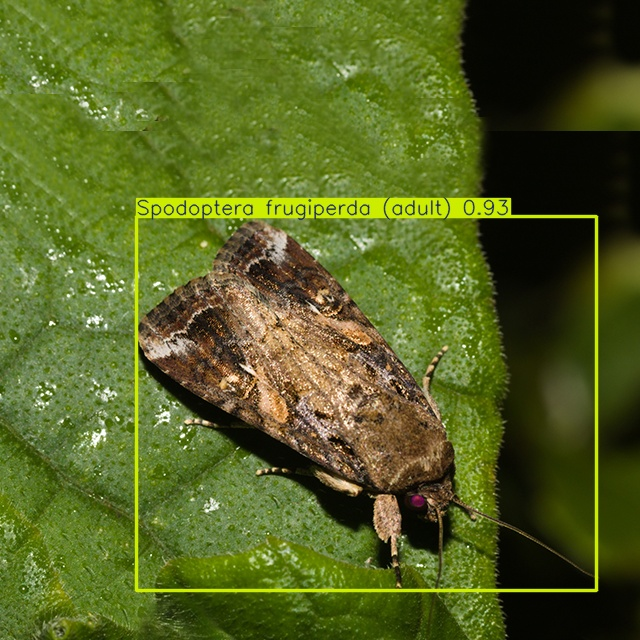

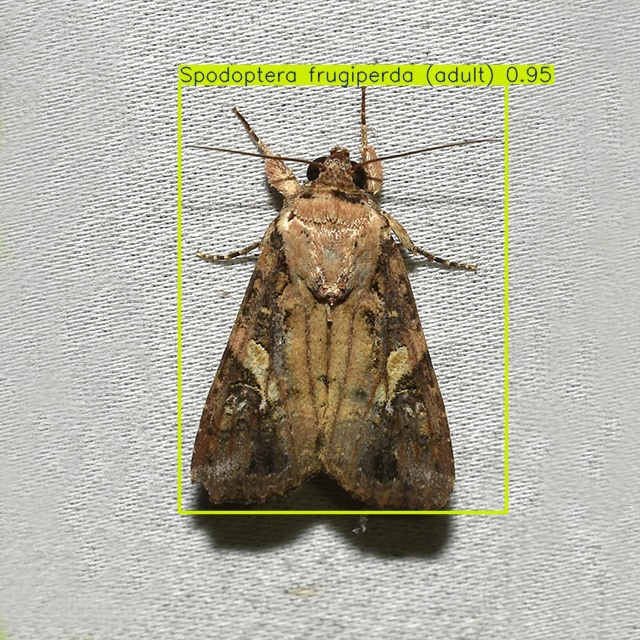

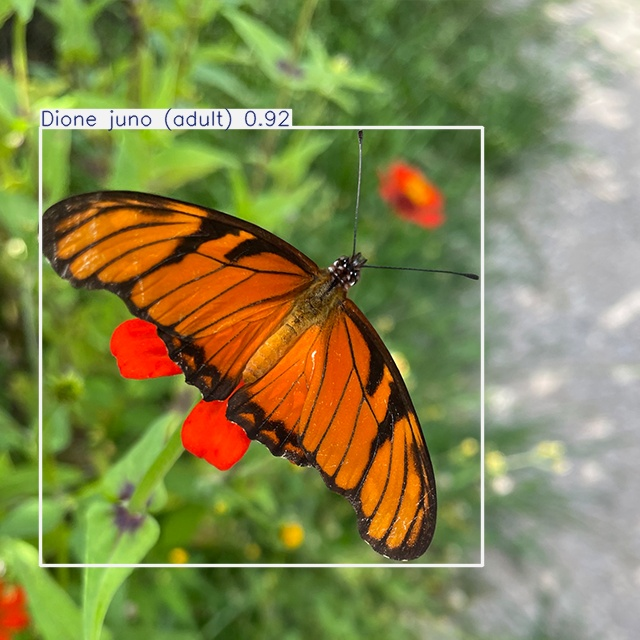

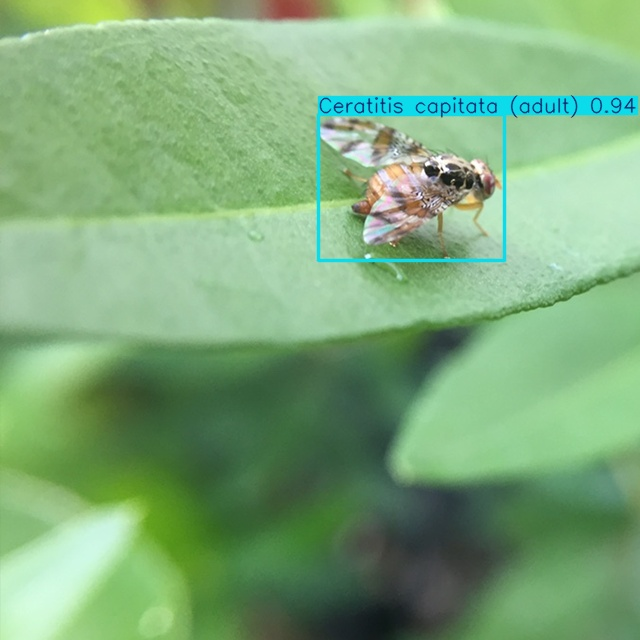

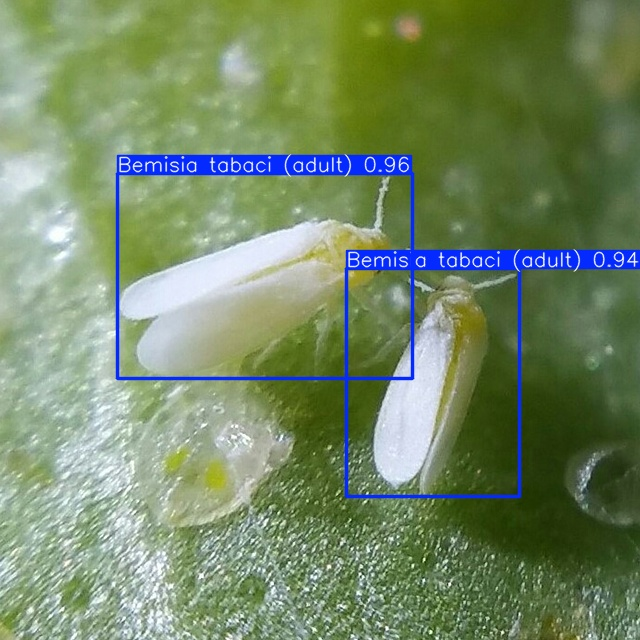

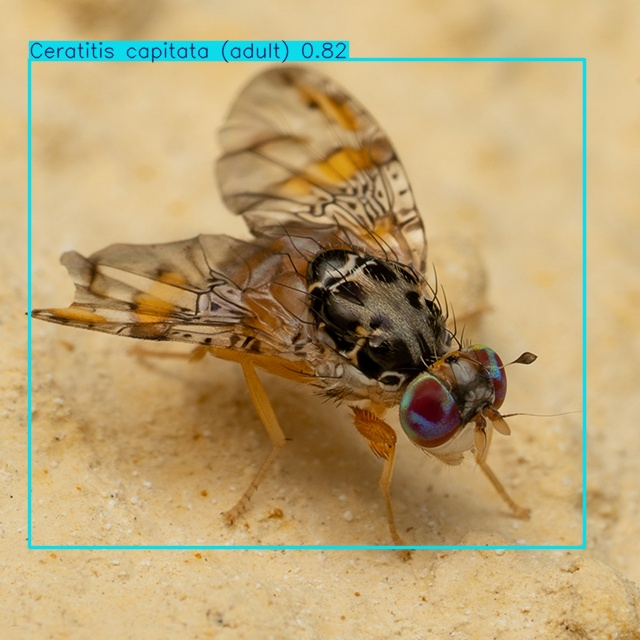

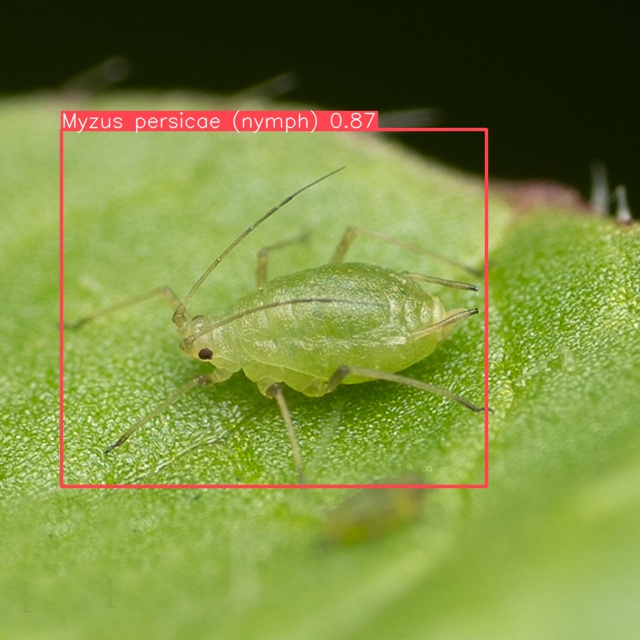

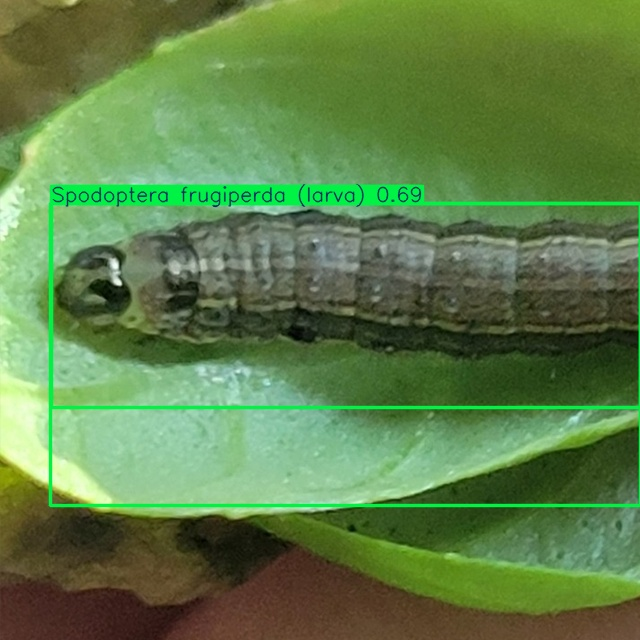

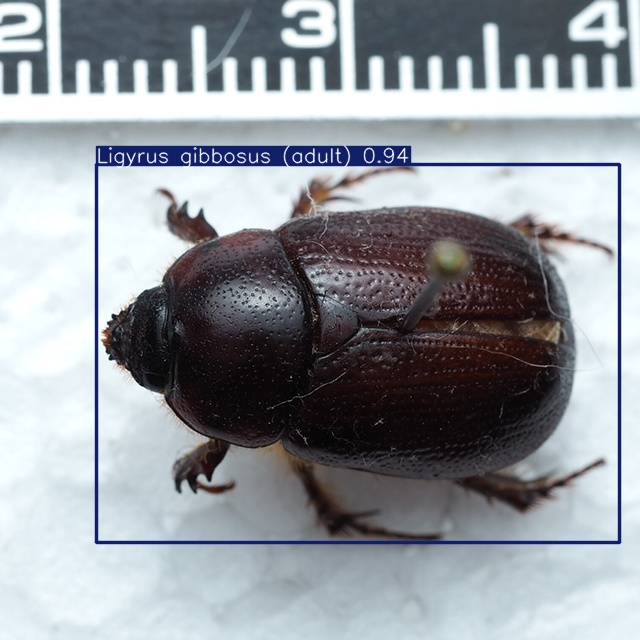

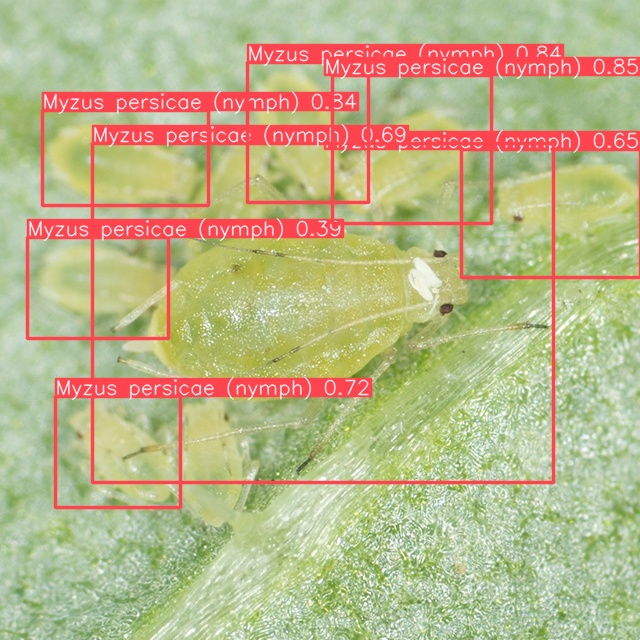

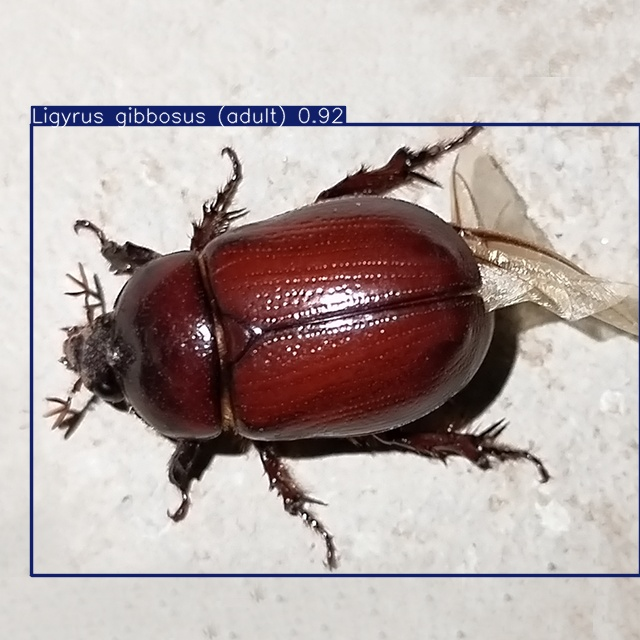

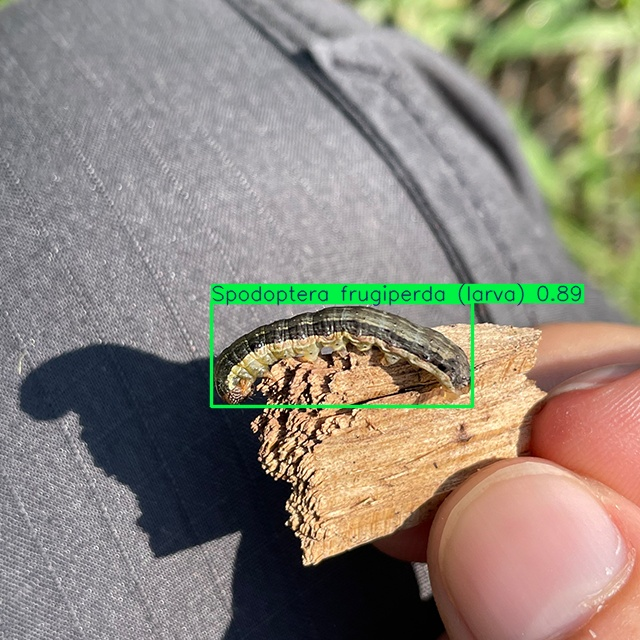

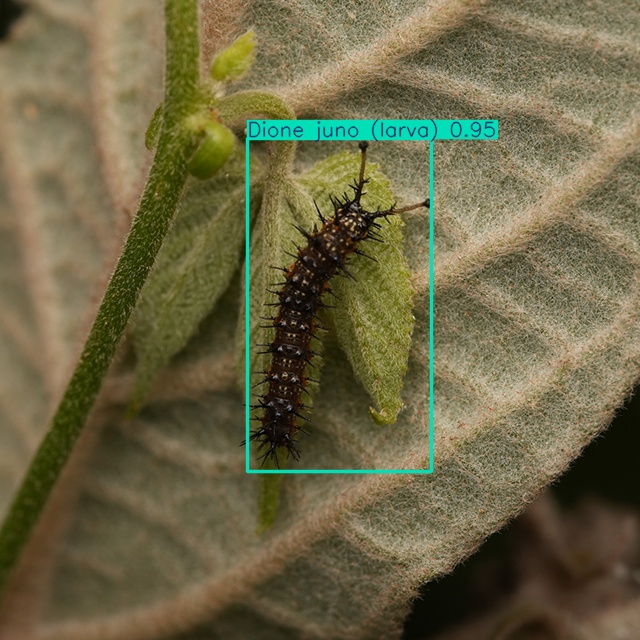

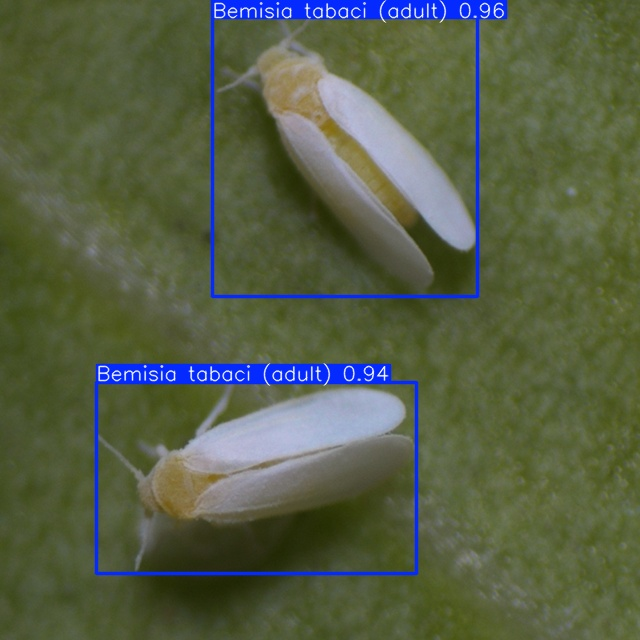

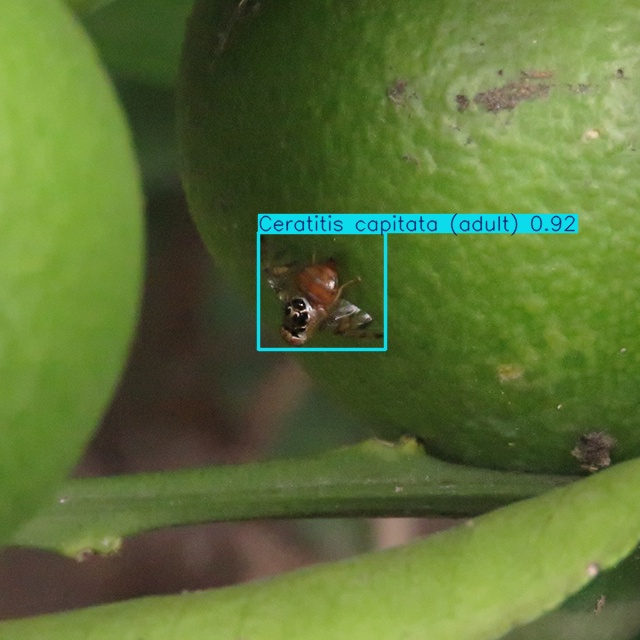

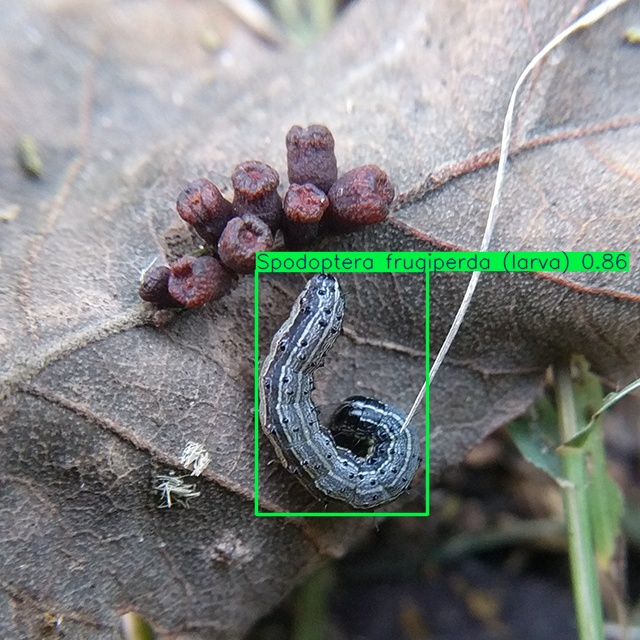

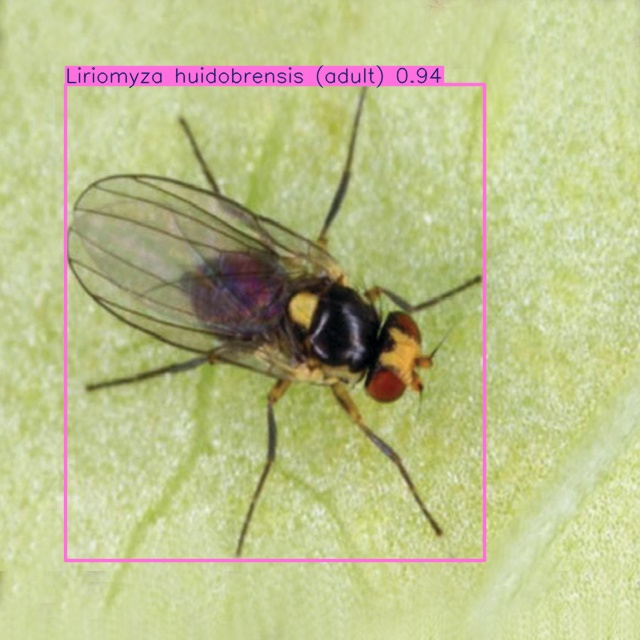

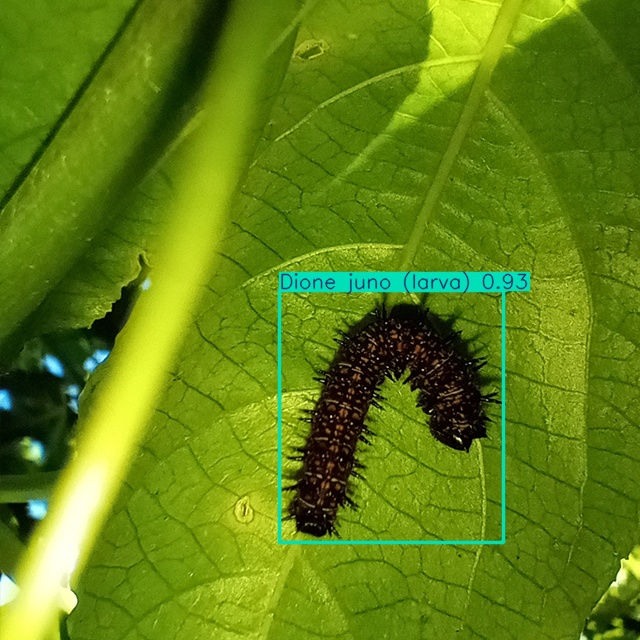

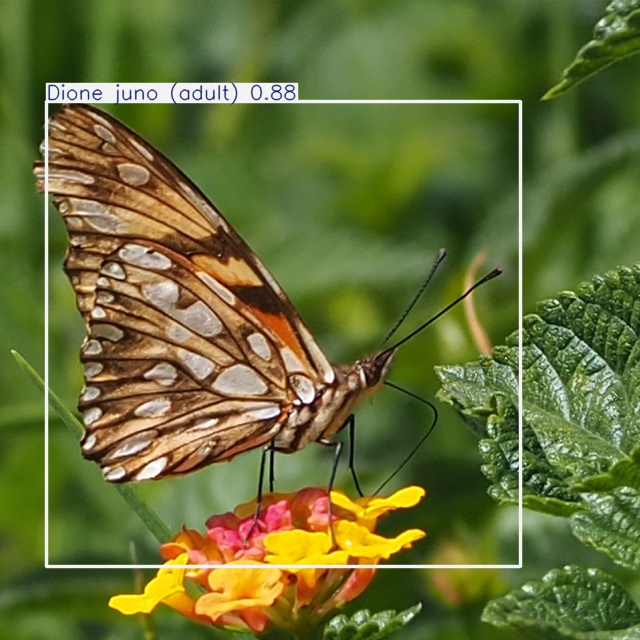

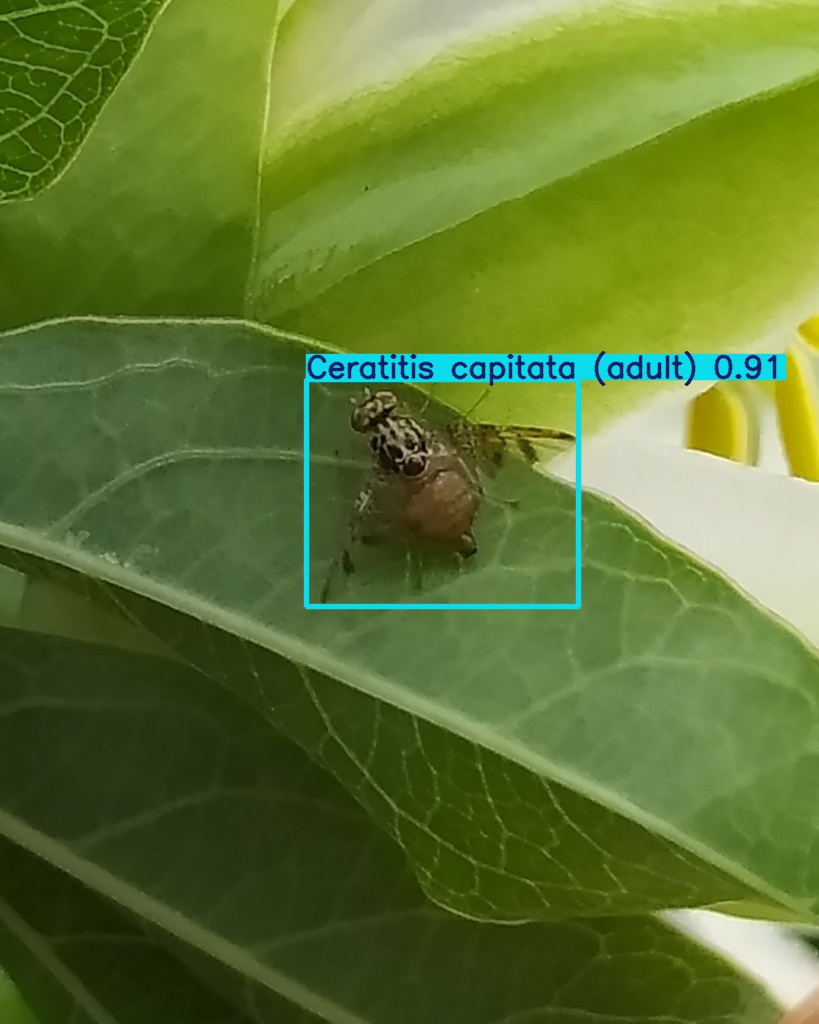

In [5]:
for image_path in glob.glob(f'runs/detect/predict/*.jpg'):
  display(Image(filename=image_path, height=400))
  print('\n')

### **Feature maps (optional)**

In [ ]:
# Trained model (PestNeuroVision)
model = YOLO('/content/trained_model/weights/best.pt') # Trained model (PestNeuroVision)

# Test dataset
source = sorted(glob.glob('/content/prediction_dataset/*'))
total = len(source)

# Note: You can see the generated activation maps in the following folder: /content/runs/detect/activation_map
for i, img in enumerate(source):
    model.predict(source=img, save=True, visualize=True, verbose=False, name=f'activation_map/image_{i}')
    print(f'Image {i+1}/{total} processed')